# Регуляризация линейной регрессии


## Что входит

1. Загрузить данные и ознакомиться с ними.
2. Изучить данные и провести анализ, сконструировать новые признаки.
3. Разделить данные на обучающую и тестовую выборки.
4. Реализовать построение модели с помощью библиотеки Scikit-learn.
5. Подобрать коэффициенты регуляризации.
6. Получить качество модели с помощью MSE, MAE, $R^2$.

## Задача
Краткое описание признаков:

* **LotArea** — размер участка в квадратных футах.
* **LotArea_M** — размер участка в квадратных метрах.
* **Street** — тип доступа к дороге.
* **BldgType** — тип жилья.
* **OverallQual** — общее качество материала и отделки.
* **OverallCond** — общая оценка состояния.
* **YearBuilt** — первоначальная дата постройки.
* **YearRemodAdd** — дата реконструкции.
* **RoofStyle** — тип крыши.
* **ExterQual** — качество материалов снаружи.
* **ExterCond** — текущее состояние материалов снаружи.
* **Foundation** — тип фундамента.
* **TotalBsmtSF** — общая площадь подвала в квадратных футах.
* **TotalBsmtSF_M** — общая площадь подвала в квадратных метрах.
* **Heating** — тип отопления.
* **HeatingQC** — качество и состояние отопления.
* **CentralAir** — кондиционирование.
* **GrLivArea** — жилая площадь в квадратных футах.
* **GrLivArea_M** — жилая площадь в квадратных метрах.
* **Bath** — количество ванных комнат.
* **KitchenQual** — качество кухни.
* **GarageArea** — площадь гаража в квадратных футах.
* **GarageArea_M** — площадь гаража в квадратных метрах.
* **DateSold** — месяц и год продажи.
* **SaleCondition** — условия сделки.
* **SalePrice** — стоимость продажи в долларах. Это целевая переменная, которую нам нужно предсказать.

Постройте модель линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE, $R^2$. Определите, что модель не переобучилась.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge,RidgeCV, Lasso, LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


In [29]:
df=pd.read_csv('data.csv')
df.head(5)

,LotArea,LotArea_M,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,...,CentralAir,GrLivArea,GrLivArea_M,Bath,KitchenQual,GarageArea,GarageArea_M,DateSold,SaleCondition,SalePrice
0,8450,785.03035,Pave,1Fam,7,5,2003,2003,Gable,Gd,...,Y,1710,158.864130,3,Gd,548,50.910844,2/2008,Normal,208500
1,9600,891.86880,Pave,1Fam,6,8,1976,1976,Gable,TA,...,Y,1262,117.243586,2,TA,460,42.735380,5/2007,Normal,181500
2,11250,1045.15875,Pave,1Fam,7,5,2001,2002,Gable,Gd,...,Y,1786,165.924758,3,Gd,608,56.485024,9/2008,Normal,223500
3,9550,887.22365,Pave,1Fam,7,5,1915,1970,Gable,TA,...,Y,1717,159.514451,1,Gd,642,59.643726,2/2006,Abnorml,140000
4,14260,1324.79678,Pave,1Fam,8,5,2000,2000,Gable,Gd,...,Y,2198,204.200794,3,Gd,836,77.666908,12/2008,Normal,250000


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotArea        1460 non-null   int64  
 1   LotArea_M      1460 non-null   float64
 2   Street         1460 non-null   str    
 3   BldgType       1460 non-null   str    
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   RoofStyle      1460 non-null   str    
 9   ExterQual      1460 non-null   str    
 10  ExterCond      1460 non-null   str    
 11  Foundation     1460 non-null   str    
 12  TotalBsmtSF    1460 non-null   int64  
 13  TotalBsmtSF_M  1460 non-null   float64
 14  Heating        1460 non-null   str    
 15  HeatingQC      1460 non-null   str    
 16  CentralAir     1460 non-null   str    
 17  GrLivArea      1460 non-null   int64  
 18  GrLivArea_M    1460

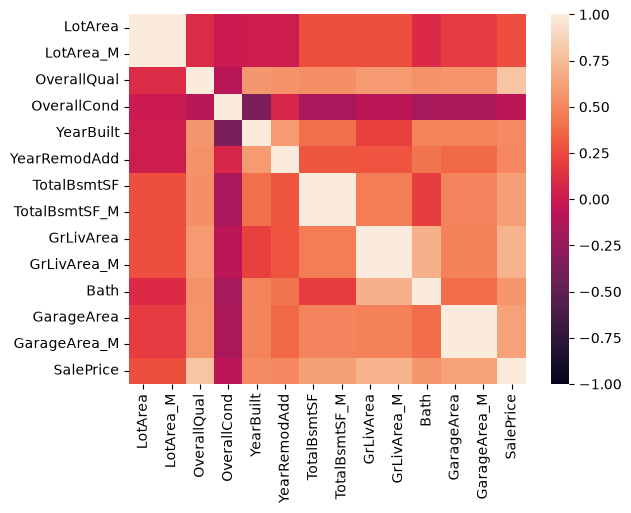

In [31]:
corr_matrix = df.select_dtypes('number').corr()
sns.heatmap(corr_matrix,vmin=-1,vmax=1);

3. Посмотрите на индивидуальные графики зависимости целевой функции и отдельной переменной.

In [32]:
drop_columns=['LotArea_M','TotalBsmtSF_M','GrLivArea_M','GarageArea_M']
df_clear=df.drop(columns=drop_columns)

In [33]:
#Без регуляризации
X = df_clear.drop(columns='SalePrice')
y = df_clear['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

numeric_features = X.select_dtypes("number").columns
categorical_features = df_clear.select_dtypes(exclude="number").columns

preprocessor = ColumnTransformer([
    ('num',StandardScaler(),numeric_features),
    ('cat',OneHotEncoder(),categorical_features)
])

model = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f'mse= {mean_squared_error(y_test,y_pred):.2f}')
print(f'mae= {mean_absolute_error(y_test,y_pred):.2f}')
print(f'r2= {r2_score(y_test,y_pred):.2f}')


mse= 1349121904.22
mae= 22509.27
r2= 0.82


In [34]:
#С регуляризацией L1
model = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',Lasso())
])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f'mse= {mean_squared_error(y_test,y_pred):.2f}')
print(f'mae= {mean_absolute_error(y_test,y_pred):.2f}')
print(f'r2= {r2_score(y_test,y_pred):.2f}')


mse= 1347692575.01
mae= 22489.22
r2= 0.82


In [35]:
#С регуляризацией L2
model = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',Ridge())
])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f'mse= {mean_squared_error(y_test,y_pred):.2f}')
print(f'mae= {mean_absolute_error(y_test,y_pred):.2f}')
print(f'r2= {r2_score(y_test,y_pred):.2f}')


mse= 1330698079.05
mae= 22266.23
r2= 0.83


In [50]:
#С регуляризацией L2 (выбираем лучшее alpha)
alphas = np.logspace(-2,3,50)

model = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',RidgeCV(alphas=alphas,cv=5))
])

model.fit(X_train,y_train)

best_alpha = model.named_steps['regressor'].alpha_

y_pred = model.predict(X_test)

print(f'best alpha: {best_alpha:.2f}')
print(f'mse= {mean_squared_error(y_test,y_pred):.2f}')
print(f'mae= {mean_absolute_error(y_test,y_pred):.2f}')
print(f'r2= {r2_score(y_test,y_pred):.2f}')

best alpha: 47.15
mse= 1318939172.02
mae= 21151.39
r2= 0.83


В последней обученной модели выберите три признака с наибольшими отрицательными коэффициентами

In [57]:
regressor_coef = model.named_steps['regressor'].coef_

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coef_feat = pd.DataFrame({
    'feature':feature_names,
    'coef':regressor_coef
})

print(coef_feat.sort_values(by='coef').head(10))

                        feature          coef
53          cat__KitchenQual_TA -10497.204540
25            cat__ExterQual_TA  -8506.992689
52          cat__KitchenQual_Gd  -7990.169915
14          cat__BldgType_Twnhs  -5681.115951
17         cat__RoofStyle_Gable  -5501.507803
109  cat__SaleCondition_Abnorml  -4915.645055
56         cat__DateSold_1/2008  -4172.776054
94         cat__DateSold_6/2009  -3314.475018
61        cat__DateSold_10/2008  -3301.865848
98         cat__DateSold_7/2008  -3222.267139
